# 5.4 自然言語推論・意味的類似度計算・多肢選択式質問応答モデルの実装

## 5.4.3 多肢選択式質問応答

### 環境の準備

In [1]:
!pip install 'transformers[ja,torch]<4.41.0'  'datasets<4.0.0' matplotlib japanize-matplotlib
!pip uninstall -y peft

Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1


In [2]:
from transformers.trainer_utils import set_seed

# 乱数シードを42に固定
set_seed(42)

### データセットの準備

In [3]:
from pprint import pprint
from datasets import load_dataset

# Hugging Face Hub上のllm-book/JGLUEのリポジトリから
# JCommonsenseQAのデータを読み込む
train_dataset = load_dataset(
    "llm-book/JGLUE",
    name="JCommonsenseQA",
    split="train"
)
valid_dataset = load_dataset(
    "llm-book/JGLUE",
    name="JCommonsenseQA",
    split="validation"
)

pprint(train_dataset[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


{'choice0': '世界',
 'choice1': '写真集',
 'choice2': '絵本',
 'choice3': '論文',
 'choice4': '図鑑',
 'label': 2,
 'q_id': 0,
 'question': '主に子ども向けのもので、イラストのついた物語が書かれているものはどれ？'}


In [4]:
pprint(train_dataset.features)

{'choice0': Value(dtype='string', id=None),
 'choice1': Value(dtype='string', id=None),
 'choice2': Value(dtype='string', id=None),
 'choice3': Value(dtype='string', id=None),
 'choice4': Value(dtype='string', id=None),
 'label': ClassLabel(names=['choice0',
                            'choice1',
                            'choice2',
                            'choice3',
                            'choice4'],
                     id=None),
 'q_id': Value(dtype='int64', id=None),
 'question': Value(dtype='string', id=None)}


### トークナイザ

In [5]:
from transformers import AutoTokenizer

model_name = "cl-tohoku/bert-base-japanese-v3"
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


### データセット登記絵の可視化

100%|██████████| 8939/8939 [00:01<00:00, 6317.25it/s]


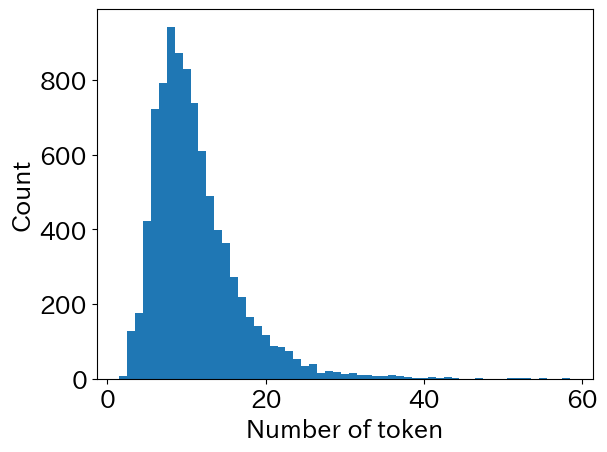

100%|██████████| 1119/1119 [00:00<00:00, 5251.74it/s]


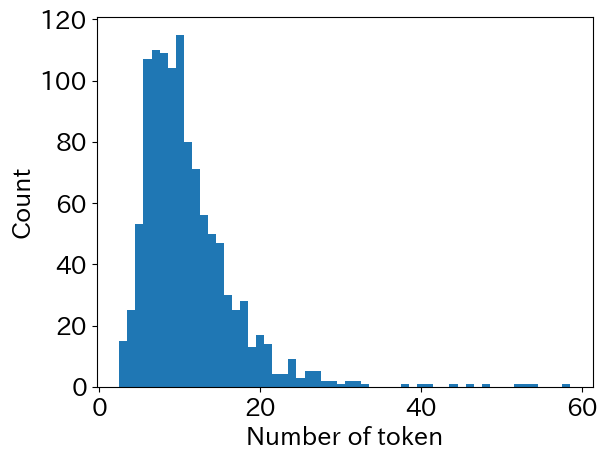

In [6]:
from collections import Counter
import japanize_matplotlib
import matplotlib.pyplot as plt
from datasets import Dataset
from tqdm import tqdm

plt.rcParams["font.size"] = 18

def visualize_question_length(dataset: Dataset):
    """データセット中の質問のトークン数を分布をグラフとして描画"""
    # データセットの中の質問の長さを数える
    length_counter = Counter()
    for data in tqdm(dataset):
        length = len(tokenizer.tokenize(data["question"]))
        length_counter[length] += 1
    
    # length_counterの値から棒グラフを描画する
    plt.bar(length_counter.keys(), length_counter.values(), width=1.0)
    plt.xlabel("Number of token")
    plt.ylabel("Count")
    plt.show()

visualize_question_length(train_dataset)
visualize_question_length(valid_dataset)

100%|██████████| 8939/8939 [00:01<00:00, 4770.66it/s]


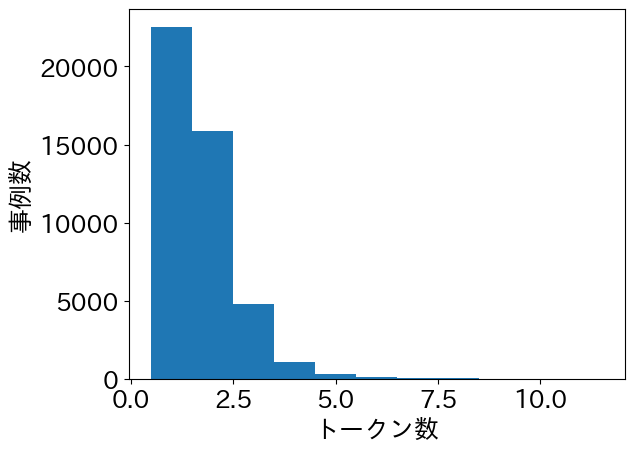

100%|██████████| 1119/1119 [00:00<00:00, 4695.76it/s]


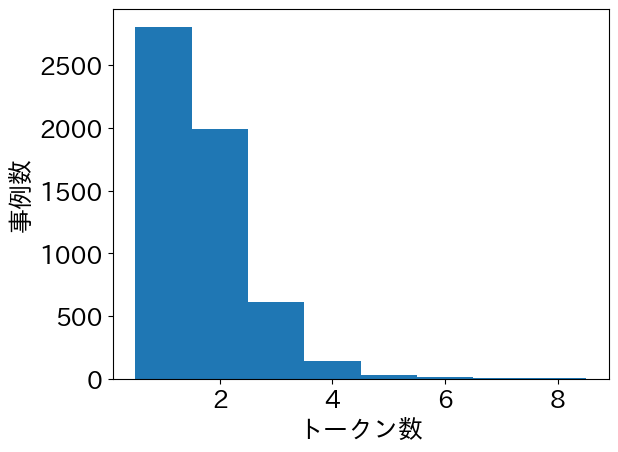

In [7]:
def visualize_choice_length(dataset: Dataset):
    """データセット中の選択肢のトークン数の分布をグラフとして描画"""
    # データセット中の選択肢の長さを数える
    length_counter = Counter()
    for data in tqdm(dataset):
        for i in range(5):
            length = len(tokenizer.tokenize(data[f"choice{i}"]))
            length_counter[length] += 1

    # length_counterの値から棒グラフを描画する
    plt.bar(length_counter.keys(), length_counter.values(), width=1.0)
    plt.xlabel("トークン数")
    plt.ylabel("事例数")
    plt.show()

visualize_choice_length(train_dataset)
visualize_choice_length(valid_dataset)

### データセットの前処理

In [8]:
from transformers import BatchEncoding

def preprocess_multiple_choice(
    example: dict[str, str]
) -> BatchEncoding:
    """多肢選択式質問応答の事例をIDに変換"""
    # 選択肢の数を"choice"から始まるキーの数として算出
    num_choices = sum(
        key.startswith("choice") for key in example.keys()
    )

    # 質問と選択肢を連結してトークナイザーに渡す
    choice_list = [example[f"choice{i}"] for i in range(num_choices)]
    repeated_question_list = [example["question"]] * num_choices
    encoded_example = tokenizer(
        repeated_question_list,
        choice_list,
        max_length=64
    )

    # ラベルが入力に含まれている場合に出力にも追加
    if "label" in example:
        encoded_example["labels"] = example["label"]
    return encoded_example

In [9]:
from transformers import AutoTokenizer

# [0]番目で動作確認
example = train_dataset[0]
encoded_example = preprocess_multiple_choice(example)  # 事例の前処理
for choice in range(5):
    # IDから元の文字列を復元
    print(tokenizer.decode(encoded_example["input_ids"][choice]))

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


[CLS] 主に 子ども 向け の もの で 、 イラスト の つい た 物語 が 書か れ て いる もの は どれ? [SEP] 世界 [SEP]
[CLS] 主に 子ども 向け の もの で 、 イラスト の つい た 物語 が 書か れ て いる もの は どれ? [SEP] 写真 集 [SEP]
[CLS] 主に 子ども 向け の もの で 、 イラスト の つい た 物語 が 書か れ て いる もの は どれ? [SEP] 絵本 [SEP]
[CLS] 主に 子ども 向け の もの で 、 イラスト の つい た 物語 が 書か れ て いる もの は どれ? [SEP] 論文 [SEP]
[CLS] 主に 子ども 向け の もの で 、 イラスト の つい た 物語 が 書か れ て いる もの は どれ? [SEP] 図鑑 [SEP]


In [10]:
encoded_train_dataset = train_dataset.map(
    preprocess_multiple_choice,
    remove_columns=train_dataset.column_names,
)
encoded_valid_dataset = valid_dataset.map(
    preprocess_multiple_choice,
    remove_columns=valid_dataset.column_names,
)

Parameter 'function'=<function preprocess_multiple_choice at 0x7e8aa06d32e0> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


Map:   0%|          | 0/8939 [00:00<?, ? examples/s]

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.


Map:   0%|          | 0/1119 [00:00<?, ? examples/s]

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.


In [11]:
print(encoded_train_dataset[0])
for choice in range(5):
    # IDから元の文字列を復元
    print(tokenizer.decode(encoded_train_dataset[4]["input_ids"][choice]))

{'input_ids': [[2, 13182, 16044, 12994, 464, 12518, 457, 384, 14930, 464, 12584, 449, 13360, 430, 14220, 494, 456, 12483, 12518, 465, 19382, 46, 3, 12575, 3], [2, 13182, 16044, 12994, 464, 12518, 457, 384, 14930, 464, 12584, 449, 13360, 430, 14220, 494, 456, 12483, 12518, 465, 19382, 46, 3, 13409, 6460, 3], [2, 13182, 16044, 12994, 464, 12518, 457, 384, 14930, 464, 12584, 449, 13360, 430, 14220, 494, 456, 12483, 12518, 465, 19382, 46, 3, 20647, 3], [2, 13182, 16044, 12994, 464, 12518, 457, 384, 14930, 464, 12584, 449, 13360, 430, 14220, 494, 456, 12483, 12518, 465, 19382, 46, 3, 15252, 3], [2, 13182, 16044, 12994, 464, 12518, 457, 384, 14930, 464, 12584, 449, 13360, 430, 14220, 494, 456, 12483, 12518, 465, 19382, 46, 3, 22929, 3]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1], [0, 0

### ミニバッチ構築

In [12]:
import torch
from transformers import BatchEncoding

def collate_fn_multiple_choice(
        features: list[BatchEncoding],
) -> dict[str, torch.Tensor]:
    """選択肢式質問応答の入力からミニバッチを構築"""
    # preprocess_multiple_choice関数に合わせてラベル名を"labels"にする
    label_name = "labels"

    batch_size = len(features)
    num_choices = len(features[0]["input_ids"])

    # 選択肢ごとの入力を一つのlistにまとめる
    flat_features = []
    for feature in features:
        flat_features += [
            {k: v[i] for k, v in feature.items() if k != label_name}
            for i in range(num_choices)
        ]

    # 選択肢ごとの入力についてパディングを行う
    flat_batch = tokenizer.pad(flat_features, return_tensors="pt")

    # 元のバッチごとに選択肢ごとの入力をまとめる
    # （バッチサイズ * 選択肢数, 最大系列長）の形をしたTensorを、
    # （バッチサイズ, 選択肢数, 最大系列長）に変換
    batch = {
        k: v.view(batch_size, num_choices, -1)
        for k, v in flat_batch.items()
    }

    # ラベルが入力に含まれている場合、バッチにまとめてTensorに変換
    if label_name in features[0]:
        labels = [feature[label_name] for feature in features]
        batch["labels"] = torch.tensor(labels, dtype=torch.int64)
    return batch

In [13]:
batch_size = 4
encoded_examples = [
    preprocess_multiple_choice(train_dataset[i])
    for i in range(batch_size)
]
batch = collate_fn_multiple_choice(encoded_examples)
pprint({name: tensor.size() for name, tensor in batch.items()})
pprint(train_dataset)

{'attention_mask': torch.Size([4, 5, 40]),
 'input_ids': torch.Size([4, 5, 40]),
 'labels': torch.Size([4]),
 'token_type_ids': torch.Size([4, 5, 40])}
Dataset({
    features: ['q_id', 'question', 'choice0', 'choice1', 'choice2', 'choice3', 'choice4', 'label'],
    num_rows: 8939
})


### モデルの準備

In [14]:
from transformers import AutoModelForMultipleChoice

model = AutoModelForMultipleChoice.from_pretrained(
    model_name,
    num_labels=train_dataset.features["label"].num_classes
)

# パラメータをメモリ上に隣接した形で配置
# これを実行しない場合、モデルの保存でエラーになることがある
for param in model.parameters():
    param.data = param.data.contiguous()

Some weights of BertForMultipleChoice were not initialized from the model checkpoint at cl-tohoku/bert-base-japanese-v3 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [15]:
model(**batch)

MultipleChoiceModelOutput(loss=tensor(1.8357, grad_fn=<NllLossBackward0>), logits=tensor([[ 0.0749, -0.1777, -0.4318,  0.3543, -0.2538],
        [-0.2200, -0.5048,  0.0775, -0.1600,  0.2931],
        [ 0.2121,  0.2197,  0.2333,  0.0482,  0.0983],
        [ 0.0969,  0.2174,  0.0648,  0.1898,  0.1869]],
       grad_fn=<ViewBackward0>), hidden_states=None, attentions=None)

### 訓練の実行

In [16]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="output_jcommonsenseqa",  # 結果の保存フォルダ
    per_device_train_batch_size=32,  # 訓練時のバッチサイズ
    per_device_eval_batch_size=32,  # 評価時のバッチサイズ
    learning_rate=2e-5,  # 学習率
    lr_scheduler_type="linear",  # 学習率スケジューラの種類
    warmup_ratio=0.1,  # 学習率のウォームアップの長さを指定
    num_train_epochs=3,  # エポック数
    save_strategy="epoch",  # チェックポイントの保存タイミング
    logging_strategy="epoch",  # ロギングのタイミング
    evaluation_strategy="epoch",  # 検証セットによる評価のタイミング
    load_best_model_at_end=True,  # 訓練後に開発セットで最良のモデルをロード
    metric_for_best_model="accuracy",  # 最良のモデルを決定する評価指標
    fp16=True,  # 自動混合精度演算の有効化
    report_to="none",  # 外部ツールへのログを無効化
)

In [17]:
import numpy as np

def compute_accuracy(
        eval_pred: tuple[np.ndarray, np.ndarray]
) -> dict[str, float]:
    """予測ラベルと正解ラベルから正解率を計算"""
    predictions, labels = eval_pred
    # predictionsは各ラベルについてのスコア
    # 最もスコアの高いインデックスを予測ラベルとする
    predictions = np.argmax(predictions, axis=1)
    return {"accuracy": (predictions == labels).mean()}

In [18]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    train_dataset=encoded_train_dataset,
    eval_dataset=encoded_valid_dataset,
    data_collator=collate_fn_multiple_choice,
    args=training_args,
    compute_metrics=compute_accuracy,
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.871400,0.472138,0.816801
2,0.438600,0.451525,0.823950
3,0.316300,0.455006,0.838248


TrainOutput(global_step=840, training_loss=0.5421085720970518, metrics={'train_runtime': 272.1687, 'train_samples_per_second': 98.531, 'train_steps_per_second': 3.086, 'total_flos': 2308796766950610.0, 'train_loss': 0.5421085720970518, 'epoch': 3.0})

### 訓練後のモデルの評価

In [19]:
# 検証セットでモデルを評価
eval_metrics = trainer.evaluate(encoded_valid_dataset)
pprint(eval_metrics)

{'epoch': 3.0,
 'eval_accuracy': 0.838248436103664,
 'eval_loss': 0.45500558614730835,
 'eval_runtime': 3.387,
 'eval_samples_per_second': 330.381,
 'eval_steps_per_second': 10.334}


### モデルの保存

#### Hugging Face Hubへの保存

In [20]:
from huggingface_hub import login
from google.colab import userdata
from huggingface_hub import login
login(token=userdata.get("HF_TOKEN"))

login()

# Hugging Face Hubのリポジトリ名
repo_name = "tact-m/bert-base-japanese-v3-output_jcommonsenceqa"
# トークナイザとモデルをアップロード
tokenizer.push_to_hub(repo_name)
model.push_to_hub(repo_name)

TimeoutException: Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.